In [1]:
import os
import json
import kagglehub
import numpy as np
import pandas as pd

#Procesamiento de Texto y Configuración
from textblob import TextBlob
from sklearn import set_config
set_config(display='diagram') 

# Visualización de Datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocesamiento y Pipelines
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

# Modelos de Regresión (Continuo)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, 
    Lars, BayesianRidge, SGDRegressor
)

# Modelos de Clasificación (Discreto)
from sklearn.linear_model import LogisticRegression

#Métricas de Evaluación
# Para Regresión
from sklearn.metrics import (
    r2_score, mean_absolute_error, 
    mean_absolute_percentage_error, mean_squared_error
)
# Para Clasificación
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
# Enviroment setup
set_config(display="diagram")
pd.set_option("display.max_columns", 50)
pd.set_option('display.float_format', lambda x: '%.8f' % x)

/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube")

print("Path to dataset files:", path)

Path to dataset files: /home/jimmii/.cache/kagglehub/datasets/datasnaek/youtube/versions/24


In [3]:
# Listar los archivos para saber el nombre exacto
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

Archivos disponibles: ['US_category_id.json', 'USvideos.csv', 'GBvideos.csv', 'GB_category_id.json', 'GBcomments.csv', 'UScomments.csv']


In [4]:
csv_path_GBvideos= os.path.join(path, 'GBvideos.csv')
df_GBvideos = pd.read_csv(csv_path_GBvideos, on_bad_lines='skip')
csv_path_GBcomments= os.path.join(path, 'GBcomments.csv')
df_GBcomments = pd.read_csv(csv_path_GBcomments, on_bad_lines='skip')

In [5]:
df_GBvideos.head(5)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date
0,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.09000000
1,AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,24,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,https://i.ytimg.com/vi/AqokkXoa7uE/default.jpg,13.09000000
2,YPVcg45W0z4,My DNA Test Results! I'm WHAT?!,emmablackery,24,emmablackery|emma blackery|emma|blackery|briti...,142819,13119,151,1141,https://i.ytimg.com/vi/YPVcg45W0z4/default.jpg,13.09000000
3,T_PuZBdT2iM,getting into a conversation in a language you ...,ProZD,1,skit|korean|language|conversation|esl|japanese...,1580028,65729,1529,3598,https://i.ytimg.com/vi/T_PuZBdT2iM/default.jpg,13.09000000
4,NsjsmgmbCfc,Baby Name Challenge!,Sprinkleofglitter,26,sprinkleofglitter|sprinkle of glitter|baby gli...,40592,5019,57,490,https://i.ytimg.com/vi/NsjsmgmbCfc/default.jpg,13.09000000


In [6]:
df_GBvideos.describe()

,category_id,views,likes,dislikes,comment_total,date
count,7993.00000000,7993.00000000,7993.00000000,7993.00000000,7993.00000000,7993.00000000
mean,19.73827099,1110732.58864006,38859.66282998,1528.85887652,4991.63117728,16.08887401
std,7.17813231,3048739.98641341,109295.07652466,8176.70778757,26837.13551816,7.67817577
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.10000000
25%,17.00000000,108375.00000000,2580.00000000,71.00000000,308.00000000,10.10000000
50%,23.00000000,315194.00000000,9561.00000000,249.00000000,1038.00000000,16.10000000
75%,24.00000000,971221.00000000,31593.00000000,867.00000000,3327.00000000,21.10000000
max,29.00000000,58961407.00000000,2289911.00000000,192725.00000000,813322.00000000,30.09000000


In [7]:
df_GBcomments.rename(columns={'likes': 'likes_comment'}, inplace=True)
df_GBcomments.rename(columns={'replies': 'replies_comment'}, inplace=True)

In [8]:
df_GBcomments.head(5)

,video_id,comment_text,likes_comment,replies_comment
0,jt2OHQh0HoQ,It's more accurate to call it the M+ (1000) be...,0,0
1,jt2OHQh0HoQ,To be there with a samsung phone\n😂😂😂,1,0
2,jt2OHQh0HoQ,"Thank gosh, a place I can watch it without hav...",0,0
3,jt2OHQh0HoQ,What happened to the home button on the iPhone...,0,0
4,jt2OHQh0HoQ,Power is the disease. Care is the cure. Keep...,0,0


In [9]:
df_GBcomments.describe()

,likes_comment,replies_comment
count,718452.00000000,718452.00000000
mean,5.23745358,0.38125024
std,203.88389330,8.96795831
min,0.00000000,0.00000000
25%,0.00000000,0.00000000
50%,0.00000000,0.00000000
75%,0.00000000,0.00000000
max,60630.00000000,521.00000000


In [10]:
df_GBcomments.shape

(718452, 4)

In [11]:
csv_path_GB_category_id = os.path.join(path, 'GB_category_id.json')
with open(csv_path_GB_category_id, 'r') as f:
    data = json.load(f)

categories = []
for category in data['items']:
    categories.append({
        'category_id': int(category['id']),
        'name': category['snippet']['title']
    })

df_GB_category_id = pd.DataFrame(categories)
df_GB_category_id.head(5)

,category_id,name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports


In [12]:
df_GBvideos.shape

(7993, 11)

In [13]:
# Unir Videos con Categorías (usando el ID)
# Esto añade la columna 'category_name' a videos
df_videos_con_cat = pd.merge(df_GBvideos, df_GB_category_id, on='category_id', how='left')

In [14]:
df_videos_con_cat.shape

(7993, 12)

In [15]:
#Agrupar por video para obtener estadísticas históricas
df_video_stats = df_videos_con_cat.groupby('video_id').agg({
    'date': 'nunique',  # ¿Cuántos días totales fue tendencia?
    'views': 'max',              # El pico máximo de vistas
    'likes': 'max',              # El pico máximo de likes
    'dislikes': 'max',           # El pico máximo de dislikes
    'comment_total': 'max',      # El pico máximo de comentarios
    'name': 'first',      # La categoría no cambia
    'title': 'first',
    'channel_title': 'first',
    'tags': 'first',
    'thumbnail_link': 'first'
}).reset_index()
# Renombrar para claridad
df_video_stats.rename(columns={'date': 'dias_en_tendencia_video',
                               'name': 'category_video',
                               'likes': 'likes_video',
                               'dislikes': 'dislikes_video',
                               'comment_total': 'comment_total_video',
                               'views': 'views_video',
                               'title':'title_video',
                               'tags': 'tags_video',
                               'thumbail_lik': 'thumbail_link_video'
                               }, inplace=True)
df_video_stats.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link
1196,f-y88NypH2U,7,1097145,56298,520,2699,People & Blogs,"PUMPKINS, PRESENTS & PLONKERS",MoreZoella,zoe sugg|zoella|zoe|vlog|vlogging|vlogs|daily|...,https://i.ytimg.com/vi/f-y88NypH2U/default.jpg
891,WMAtfhATTLg,8,949018,52070,277,3029,Music,Sam Smith - The Thrill Of It All (Album Trailer),SamSmithWorldVEVO,Sam|Smith|Album|Trailer|Capitol|Pop,https://i.ytimg.com/vi/WMAtfhATTLg/default.jpg
99,2XIuFmRBCv4,2,38796,101,6,26,Entertainment,Northern woman biting people over kebab,Nintendoid64,Northen|Northern Ireland|Ireland|North|Norther...,https://i.ytimg.com/vi/2XIuFmRBCv4/default.jpg
912,Wv3RpLvPasE,1,346221,3402,87,157,Music,MACKLEMORE FEAT OTIENO TERRY - LEVITATE,Macklemore LLC,macklemore|music|seattle|macklemore & ryan lew...,https://i.ytimg.com/vi/Wv3RpLvPasE/default.jpg
970,YwlNtzq2k1M,1,37402,1999,99,182,People & Blogs,How to have a Successful Holiday Fling | Hanna...,Hannah Witton,how to have a successful holiday fling|holiday...,https://i.ytimg.com/vi/YwlNtzq2k1M/default.jpg
943,Y61Q5w8qdSw,6,1196366,81052,12941,12862,Entertainment,IT PENNYWISE GLAM HALLOWEEN MAKEUP TUTORIAL,James Charles,james|james charles|charles|makeup|mua|makeup ...,https://i.ytimg.com/vi/Y61Q5w8qdSw/default.jpg
1464,q68xUVH3qiM,5,233096,5477,468,509,People & Blogs,Nick Kroll & John Mulaney Give Teens Puberty A...,BuzzFeed Celeb,buzzfeed|buzzfeed video|buzzfeed celeb|buzzfee...,https://i.ytimg.com/vi/q68xUVH3qiM/default.jpg
423,FfRGxN2zeWU,7,2698525,42006,1676,5067,Entertainment,Angelica Hale: 10-Year-Old Singer Blows The Au...,America's Got Talent,America's Got Talent 2017|america's got talent...,https://i.ytimg.com/vi/FfRGxN2zeWU/default.jpg
920,XJK8GXVvKkA,1,1884820,55235,1132,3279,Comedy,How To Be Honest | Awkward Puppets,Awkward Puppets,how to be honest|awkward|puppets|how|to|be|hon...,https://i.ytimg.com/vi/XJK8GXVvKkA/default.jpg
1256,hWYZwNRtQ-8,5,365683,614,162,665,Sports,Chile vs Ecuador 2-1 ● Goals & Highlights Gole...,MATCHDAY HIGHLIGHTS,Chile vs Ecuador 2-1 ● Goals & Highlights Gole...,https://i.ytimg.com/vi/hWYZwNRtQ-8/default.jpg


In [16]:
df_video_stats.shape

(1736, 11)

Sentiment Analysis	Determines the emotional tone (polarity: -1 to 1) and objectivity (subjectivity: 0 to 1).	blob.sentiment

In [17]:
# Función para obtener solo la polaridad (sentimiento)
def get_sentiment(text):
    try:
        # Convertimos a string por si hay valores nulos o números
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

# Aplicamos al dataset original de comentarios
df_GBcomments['sentiment_score'] = df_GBcomments['comment_text'].apply(get_sentiment)

In [18]:
df_GBcomments.sample(10)

,video_id,comment_text,likes_comment,replies_comment,sentiment_score
235622,chfg6YYiQpU,"Omg love that new huda beauty palette, I've be...",0,0,0.50727273
486995,76WkDuiAjeY,B,0,0,0.00000000
15919,T6lon9-8Fck,GIVE ME A SLICE OF THAT HEARTHSTONE MONEY FOR ...,0,0,-0.50000000
207692,h4JP6su_mio,I don’t think ultra boosts are worth it,0,0,0.30000000
425368,KPqtlI3aJIE,Adele & Sam collab needs to happen soon!,1,0,0.00000000
112378,8sDXUWNYwIM,I love this channel . Dan Lawless please get r...,3,0,0.50000000
337715,JV1NB70gLQI,Please make more awesome videos on corporation...,0,0,0.52000000
196169,pMZAhWZxdGI,Can someone smart explain this weird video 😑,0,0,-0.14285714
352923,_StIv9i6as4,Can I just say I can't wait for season two to ...,0,0,-0.18750000
94763,E-6LUtmwymo,I love shawn❤️,1,0,0.50000000


In [19]:
#Resumimos los comentarios
resumen_comentarios = df_GBcomments.groupby('video_id').agg({
    'comment_text': 'count',      # Total de renglones
    'likes_comment': 'mean',      # Promedio de likes por comentario
    'replies_comment':'mean',
    'sentiment_score': 'mean'        # Promedio de sentimiento
}).rename(columns={
    'likes_comment':'promedio_likes_por_comentario',
    'replies_comment':'promedio_replies_por_comentario',
    'comment_text': 'conteo_real_comentarios',
    'sentiment_score': 'sentimiento_promedio'})
resumen_comentarios.head(5)

,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
video_id,,,,
--JinobXWPk,300,0.20000000,0.01333333,0.03773691
--y69Ui8xwM,291,3.87285223,0.98969072,0.17029046
-1fzGnFwz9M,200,8.75000000,0.20500000,0.13654245
-2hRYEFiPSA,700,1.45714286,0.09285714,0.23986667
-6Zc8Co2H3w,799,0.11000000,0.00375000,0.20554525


In [20]:
# Lo unimos al de videos (Cada video sigue siendo una sola fila)
df = pd.merge(df_video_stats, resumen_comentarios, on='video_id', how='left')

In [21]:
df.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
1582,uLP8rFrL1W0,3,95042,4588,33,758,People & Blogs,King Gizzard & The Lizard Wizard - Crumbling C...,Flightless,king gizzard and the lizard wizard|crumbling c...,https://i.ytimg.com/vi/uLP8rFrL1W0/default.jpg,300.00000000,0.95000000,0.07666667,0.09902343
1125,cWF_xpeQzsQ,6,1507,0,0,0,People & Blogs,Kinder Surprise advert Hotwheels and Happy Kit...,ModelCollector2005,[none],https://i.ytimg.com/vi/cWF_xpeQzsQ/default.jpg,NaN,NaN,NaN,NaN
179,5YNUrPpQZmg,3,120213,992,287,0,Entertainment,Penny Lancaster Bravely Shares Her Experience ...,Loose Women,loose women|interview|Chat Shows - Topic|Chat ...,https://i.ytimg.com/vi/5YNUrPpQZmg/default.jpg,NaN,NaN,NaN,NaN
968,YrTKLZi6rqk,5,146530,9308,44,646,Howto & Style,GET READY WITH ME! - ft. old friend,Madeyewlook,Halloween|makeup tutorial|body painting|hallow...,https://i.ytimg.com/vi/YrTKLZi6rqk/default.jpg,500.00000000,13.30800000,0.50000000,0.27529817
1674,xV1dMqeb4_U,7,92748,2625,43,176,Music,Julien Baker - Turn Out The Lights,Matador Records,[none],https://i.ytimg.com/vi/xV1dMqeb4_U/default.jpg,679.00000000,3.63622975,0.17967599,0.18300525
1562,tl6w1-IlyDs,6,3182521,173432,1395,11913,People & Blogs,I Dressed Like Store Mannequins For A Week,Safiya Nygaard,fashion|i dressed like store mannequins for a ...,https://i.ytimg.com/vi/tl6w1-IlyDs/default.jpg,600.00000000,63.36500000,3.17333333,0.20329048
955,YQYslaA1Lus,4,327306,12975,343,1231,Music,How Kanye West’s ‘Graduation’ Changed Music | ...,Genius,genius|rap genius|verified|official lyrics|lyr...,https://i.ytimg.com/vi/YQYslaA1Lus/default.jpg,400.00000000,0.13500000,0.00750000,0.16963751
1349,lIY6zFL95hE,8,6639262,149506,2203,16771,Entertainment,Marvel's The Punisher | Official Trailer [HD] ...,Netflix,Netflix|Trailer|streaming|movies online|docume...,https://i.ytimg.com/vi/lIY6zFL95hE/default.jpg,800.00000000,0.10250000,0.04875000,0.11658024
702,PnbKgdNUPlM,3,15754,2216,23,250,Comedy,How to Vlog (feat. TomSka),Ami Yamato,Vlog|UK|London|Japan|Japanese|Vlogging tips|Ho...,https://i.ytimg.com/vi/PnbKgdNUPlM/default.jpg,300.00000000,2.64000000,0.14666667,0.26661392
562,KuPGRc6EKCo,2,220483,6752,853,1455,People & Blogs,WE MIGHT HAVE TO EVACUATE!,Charles and Allie - CTFxC,Charles Trippy|CTFxC|Charles and Allie|Charles...,https://i.ytimg.com/vi/KuPGRc6EKCo/default.jpg,200.00000000,0.11000000,0.07000000,0.08725104


In [22]:
df.describe()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
count,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1692.00000000,1692.00000000,1692.00000000,1692.00000000
mean,4.60426267,1098906.06278802,36468.51497696,1376.80414747,4531.63306452,424.60047281,6.05145744,0.47979560,0.15256586
std,2.30562880,3217177.32470670,106660.44285226,7062.17035149,23740.09892236,249.55224708,39.10342068,2.89146457,0.11138181
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,2.00000000,0.00000000,0.00000000,-0.16505556
25%,3.00000000,99108.00000000,2239.00000000,62.00000000,276.00000000,200.00000000,0.15500000,0.01875000,0.07215760
50%,5.00000000,295596.50000000,8432.00000000,226.00000000,906.00000000,400.00000000,0.50000000,0.08333333,0.13984750
75%,6.00000000,937798.25000000,28482.75000000,783.00000000,3027.50000000,600.00000000,2.75572963,0.39196311,0.22559532
max,12.00000000,58961407.00000000,2289911.00000000,192725.00000000,813322.00000000,1200.00000000,1311.50000000,114.00000000,0.60000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   video_id                         1736 non-null   object 
 1   dias_en_tendencia_video          1736 non-null   int64  
 2   views_video                      1736 non-null   int64  
 3   likes_video                      1736 non-null   int64  
 4   dislikes_video                   1736 non-null   int64  
 5   comment_total_video              1736 non-null   int64  
 6   category_video                   1732 non-null   object 
 7   title_video                      1736 non-null   object 
 8   channel_title                    1736 non-null   object 
 9   tags_video                       1736 non-null   object 
 10  thumbnail_link                   1736 non-null   object 
 11  conteo_real_comentarios          1692 non-null   float64
 12  promedio_likes_por_c

In [24]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)

In [25]:
ls_cont = df.select_dtypes(include='number').columns.to_list()
ls_disc = df.select_dtypes(include=object).columns.to_list()
ls_cont,ls_disc


(['dias_en_tendencia_video',
  'views_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'conteo_real_comentarios',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio'],
 ['video_id',
  'category_video',
  'title_video',
  'channel_title',
  'tags_video',
  'thumbnail_link'])

El conteo_real_comentarios_es la cuenta de cuantos comentarios habia de cada video en el data set de comentarios, no coincide con el comment_ total probablemente por que este limitado la cantidad de datos que trae o algo por el estilo

### EDA continuas

In [26]:
for col in ls_cont:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

#### EDA discretas

In [27]:
items_a_quitar = ["video_id", "title_video", "thumbnail_link"]
ls_disc = [x for x in ls_disc if x not in items_a_quitar]

In [28]:
for col in ls_disc:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

In [29]:
freq_discrete(df, ls_disc)

Feature: category_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
category_video,,,,
Entertainment,319,18.38%,319,18.38%
Music,280,16.13%,599,34.50%
Howto & Style,252,14.52%,851,49.02%
People & Blogs,245,14.11%,"1,096",63.13%
Sports,164,9.45%,"1,260",72.58%
Comedy,124,7.14%,"1,384",79.72%
Film & Animation,76,4.38%,"1,460",84.10%
News & Politics,68,3.92%,"1,528",88.02%
Gaming,65,3.74%,"1,593",91.76%


Feature: channel_title


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
channel_title,,,,
The Tonight Show Starring Jimmy Fallon,16,0.92%,16,0.92%
Vox,12,0.69%,28,1.61%
PointlessBlogVlogs,12,0.69%,40,2.30%
Jimmy Kimmel Live,11,0.63%,51,2.94%
Amelia Liana,10,0.58%,61,3.51%
...,...,...,...,...
My Pale Skin,1,0.06%,"1,732",99.77%
Ibz Mo,1,0.06%,"1,733",99.83%
LQENTERTAINMENT,1,0.06%,"1,734",99.88%


Feature: tags_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
tags_video,,,,
[none],86,4.95%,86,4.95%
family|mom|mommy|baby|children|kids|mother|father|dad|son|daughter|home|young family|sacconejolys|video dairy|real life|reality tv|london|jonathan|joly|anna|saccone,9,0.52%,95,5.47%
James Corden|The Late Late Show|Colbert|late night|late night show|Stephen Colbert|Comedy|monologue|comedian|impressions|celebrities|carpool|karaoke|CBS|Late Late Show|Corden|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous,7,0.40%,102,5.88%
The Late Show|Stephen Colbert|Colbert|Late Show|celebrities|late night|talk show|skits|bit|monologue|The Late Late Show|Late Late Show|letterman|david letterman|comedian|impressions|CBS|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous|James Corden|Corden|Comedy,5,0.29%,107,6.16%
the real|daytime|talk show|women|tamera mowry|adrienne bailon|loni love|jeannie mai,5,0.29%,112,6.45%
...,...,...,...,...
Jolly|JOLLY|jolly|졸리|조쉬|조시|올리|josh|ollie|korean|englishman|외국인|영국남자|새로운|채널|second|사생활|new|channel|한국말|UK|영국|런던,1,0.06%,"1,732",99.77%
recipe|recipes|how to make|how to bake|cooking|food|sweets|dessert|cute|easy|quick|kawaii|kawaii baking|kawaiisweetworld|kawaii food|cute food|cute baking|cute dessert|kawaii dessert|easy baking|simple baking|kawaii recipes|cute recipes|baking recipes|Pusheen|Pusheen dessert|Pusheen recipe|Pusheen cat|Pusheen DIY|brownie pops|brownie recipe|best chocolate brownies|best brownie recipe|best ever brownies,1,0.06%,"1,733",99.83%
Jim Carrey|Fashion Week|Fashion|Red Carpet|E! Live from the Red Carpet|Celebrity Gossip|Celebrity News|E! News|E! Entertainment|E!|Pop Culture|Live|Interviews|Awards|Award Show|Beauty|Oscars|Grammys|Golden Globes|Emmys,1,0.06%,"1,734",99.88%


## Feature Engeneering

### Categorias de video aplicamos One Hot Encoder

In [30]:
# Instanciamos el codificador
# drop='first' para evitar la multicolinealidad en Regresión Lineal
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='error', dtype=np.int64)

categorias_codificadas = ohe.fit_transform(df[['category_video']])

df_ohe = pd.DataFrame(
    categorias_codificadas, 
    columns=ohe.get_feature_names_out(['category_video']),
    index=df.index
)
df_ohe

,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None
0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1732,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1733,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1734,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [31]:
print("Categoría eliminada (referencia):", ohe.categories_[0][0])

Categoría eliminada (referencia): Autos & Vehicles


In [32]:
#Unimos al dataframe original y eliminamos la columna de texto
df= pd.concat([df, df_ohe], axis=1).drop(columns=['category_video'])
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,Brave Wilderness,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,LilWiz,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,Simon's Cat,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,LPAssociation,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),Screen Junkies,screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,LaurDIY,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,makeupbymichaelfinch,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Movieclips Film Festivals & Indie Films,Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0


### channel_title usamos Agrupación por "Fuerza del Canal" (Binning)

In [33]:
# Contamos las apariciones por canal
canal_counts = df['channel_title'].value_counts()

# Mapeamos ese conteo de vuelta al dataframe original
df['canal_frecuencia'] = df['channel_title'].map(canal_counts)

In [34]:
canal_counts

channel_title
The Tonight Show Starring Jimmy Fallon    16
Vox                                       12
PointlessBlogVlogs                        12
Jimmy Kimmel Live                         11
Amelia Liana                              10
                                          ..
My Pale Skin                               1
Ibz Mo                                     1
LQENTERTAINMENT                            1
Twosdays With Tk                           1
TMZSports                                  1
Name: count, Length: 1001, dtype: int64

In [35]:
# Definimos los umbrales usando percentiles
top_threshold = df['canal_frecuencia'].quantile(0.95)
mid_threshold = df['canal_frecuencia'].quantile(0.50)

# Función para categorizar
def categorizar_canal(frecuencia):
    if frecuencia >= top_threshold:
        return 'Top Tier'
    elif frecuencia >= mid_threshold:
        return 'Mid Tier'
    else:
        return 'Small Tier'

# Aplicamos el binning
df['fuerza_canal'] = df['canal_frecuencia'].apply(categorizar_canal)

In [36]:
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,canal_frecuencia,fuerza_canal
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,Brave Wilderness,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,6,Mid Tier
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,LilWiz,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,Small Tier
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,Simon's Cat,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4,Mid Tier
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,LPAssociation,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,Small Tier
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,Mid Tier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),Screen Junkies,screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,Mid Tier
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,LaurDIY,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,Mid Tier
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,makeupbymichaelfinch,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,Mid Tier
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Movieclips Film Festivals & Indie Films,Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,Small Tier


In [37]:
ohe_canal = OneHotEncoder(sparse_output=False, drop='first', dtype=int)
fuerza_encoded = ohe_canal.fit_transform(df[['fuerza_canal']])

# Crear el DataFrame con los nombres de las columnas 
df_fuerza = pd.DataFrame(
    fuerza_encoded, 
    columns=ohe_canal.get_feature_names_out(['fuerza_canal']),
    index=df.index
)

# Unimos y limpiamos
df = pd.concat([df, df_fuerza], axis=1)
# Ya no necesitamos ni el título original ni la frecuencia numérica
df.drop(columns=['channel_title', 'canal_frecuencia', 'fuerza_canal'], inplace=True)

In [38]:
#Se utilizó la categoría Mid Tier como base de referencia.
print("Categoría eliminada (referencia):", ohe_canal.categories_[0][0])

Categoría eliminada (referencia): Mid Tier


In [39]:
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


### tags_video 

In [40]:
# Variable Continua: Cantidad de etiquetas
# Contamos cuántas palabras separadas por '|' hay. Si dice '[none]', ponemos 0.
df['cantidad_tags'] = df['tags_video'].apply(lambda x: len(str(x).split('|')) if x != '[none]' else 0)

# Variable Binaria: ¿Tiene etiquetas? 
# 1 si tiene contenido, 0 si no tiene nada ([none])
df['tiene_tags'] = df['tags_video'].apply(lambda x: 0 if x == '[none]' else 1)

# Variable Continua: Longitud del texto de los tags
# Esto mide qué tan descriptivas son las etiquetas en total
df['longitud_tags_texto'] = df['tags_video'].apply(lambda x: len(str(x)) if x != '[none]' else 0)

df.drop(columns=['tags_video'], inplace=True)
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33,1,456
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,23,1,381
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,44,1,445
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4,1,58
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,15,1,239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,11,1,155
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,23,1,309
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,1,25
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,23,1,206


In [41]:
df.drop(columns=items_a_quitar,inplace=True)

In [42]:
ls_cont.append("cantidad_tags")
ls_cont.append("longitud_tags_texto")
df.sample(10)

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
1175,3,1465456,75278,1188,4582,300.00000000,0.66333333,0.09000000,0.24536707,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,6,1,60
805,5,184611,2057,75,206,353.00000000,6.09065156,0.60056657,0.07988343,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,10,1,77
972,6,1260662,2515,116,798,599.00000000,0.27212020,0.03005008,-0.06543970,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,6,1,77
1114,3,66845,5118,142,699,300.00000000,0.90333333,0.10000000,0.28221463,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4,1,41
1657,2,429647,30194,329,2358,200.00000000,21.52000000,0.47000000,0.17231937,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,28,1,194
60,9,2011045,119765,2063,6464,900.00000000,0.20000000,0.02666667,0.32305255,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,14,1,95
48,7,948618,10380,765,1679,700.00000000,0.14714286,0.00428571,0.12827712,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,16,1,232
597,3,976036,27556,861,2401,300.00000000,0.27333333,0.02333333,-0.00062625,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,128
331,5,2162234,41029,1384,5084,500.00000000,0.16800000,0.00400000,0.03852918,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,14,1,109
0,3,1874297,46933,653,7500,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33,1,456


In [43]:
ls_bin=["category_video_Comedy","category_video_Education","category_video_Entertainment",
        "category_video_Film & Animation","category_video_Gaming","category_video_Howto & Style",
        "category_video_Music","category_video_News & Politics","category_video_People & Blogs",
        "category_video_Pets & Animals","category_video_Science & Technology","category_video_Sports",
        "category_video_Travel & Events","category_video_None","fuerza_canal_Small Tier",
        "fuerza_canal_Top Tier","tiene_tags"]
ls_cont,ls_bin

(['dias_en_tendencia_video',
  'views_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'conteo_real_comentarios',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio',
  'cantidad_tags',
  'longitud_tags_texto'],
 ['category_video_Comedy',
  'category_video_Education',
  'category_video_Entertainment',
  'category_video_Film & Animation',
  'category_video_Gaming',
  'category_video_Howto & Style',
  'category_video_Music',
  'category_video_News & Politics',
  'category_video_People & Blogs',
  'category_video_Pets & Animals',
  'category_video_Science & Technology',
  'category_video_Sports',
  'category_video_Travel & Events',
  'category_video_None',
  'fuerza_canal_Small Tier',
  'fuerza_canal_Top Tier',
  'tiene_tags'])

## Cleaning Data

### DETECCIÓN Y REMOCIÓN DE VALORES EXTREMOS (OUTLIERS)

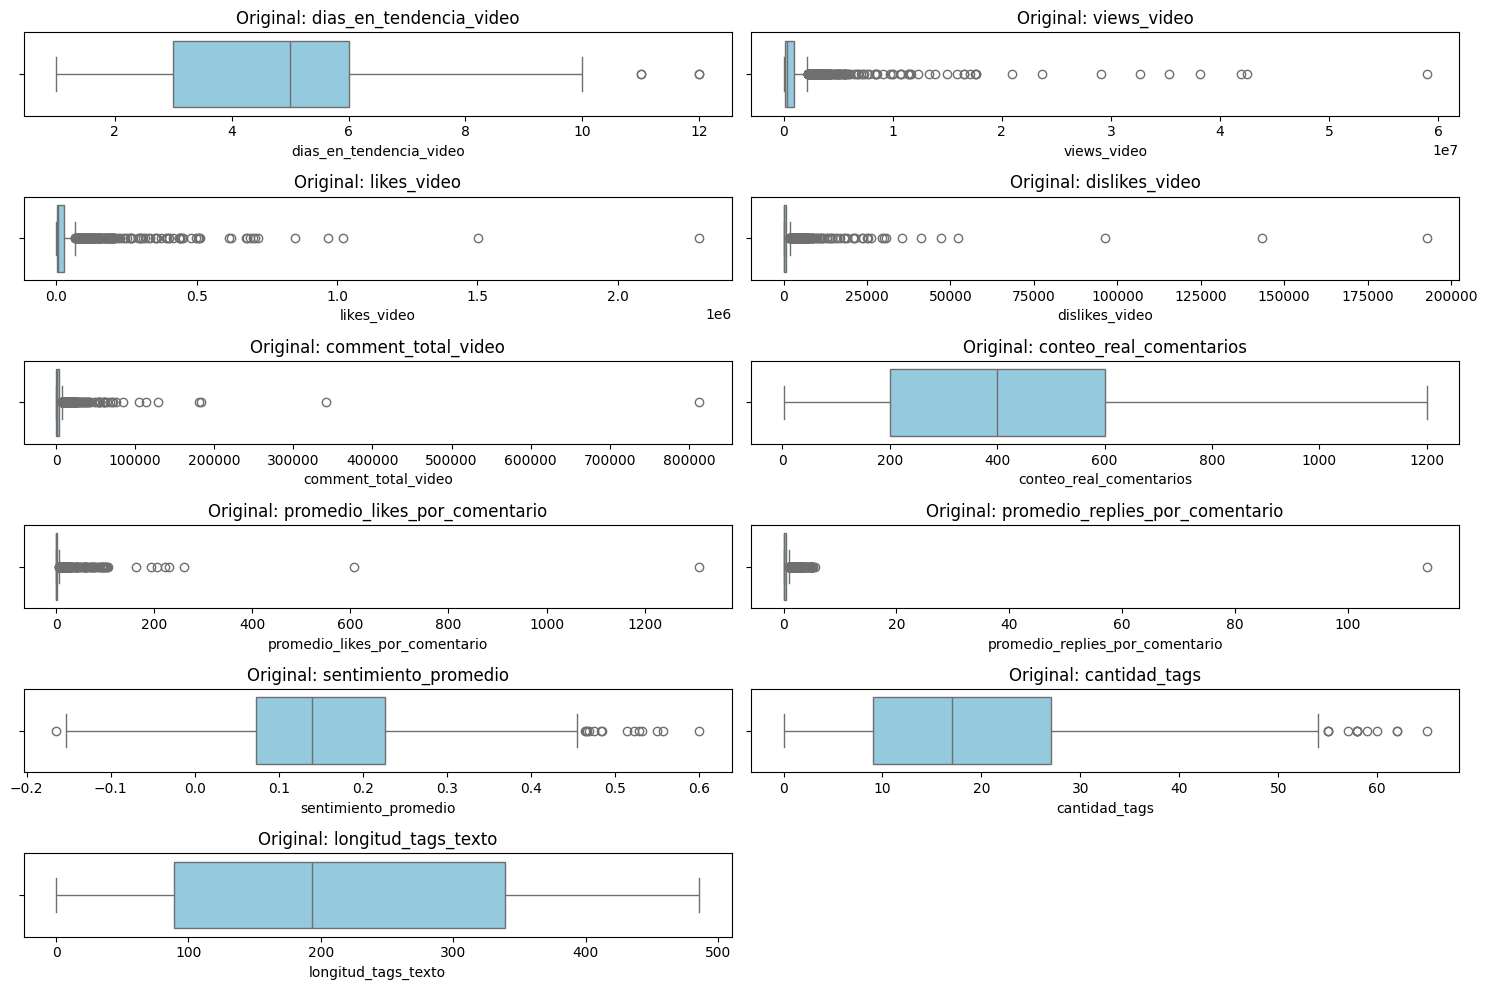

Conteo de Outliers por columna:
dislikes_video                     230
promedio_likes_por_comentario      210
comment_total_video                209
likes_video                        207
promedio_replies_por_comentario    200
views_video                        187
sentimiento_promedio                15
cantidad_tags                       13
dias_en_tendencia_video              4
conteo_real_comentarios              0
longitud_tags_texto                  0
dtype: int64


In [44]:
numeric_cols = ls_cont 
# Convertimos a float para que acepten los límites decimales del IQR
for col in numeric_cols:
    df[col] = df[col].astype('float64')

# Configuración de los cálculos IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df.reset_index(drop=True)

# Visualización ANTES de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Original: {col}')

plt.tight_layout()
plt.show()

# Mostrar el conteo de outliers 
outliers_mask = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
print("Conteo de Outliers por columna:")
print(outliers_mask.sum().sort_values(ascending=False))

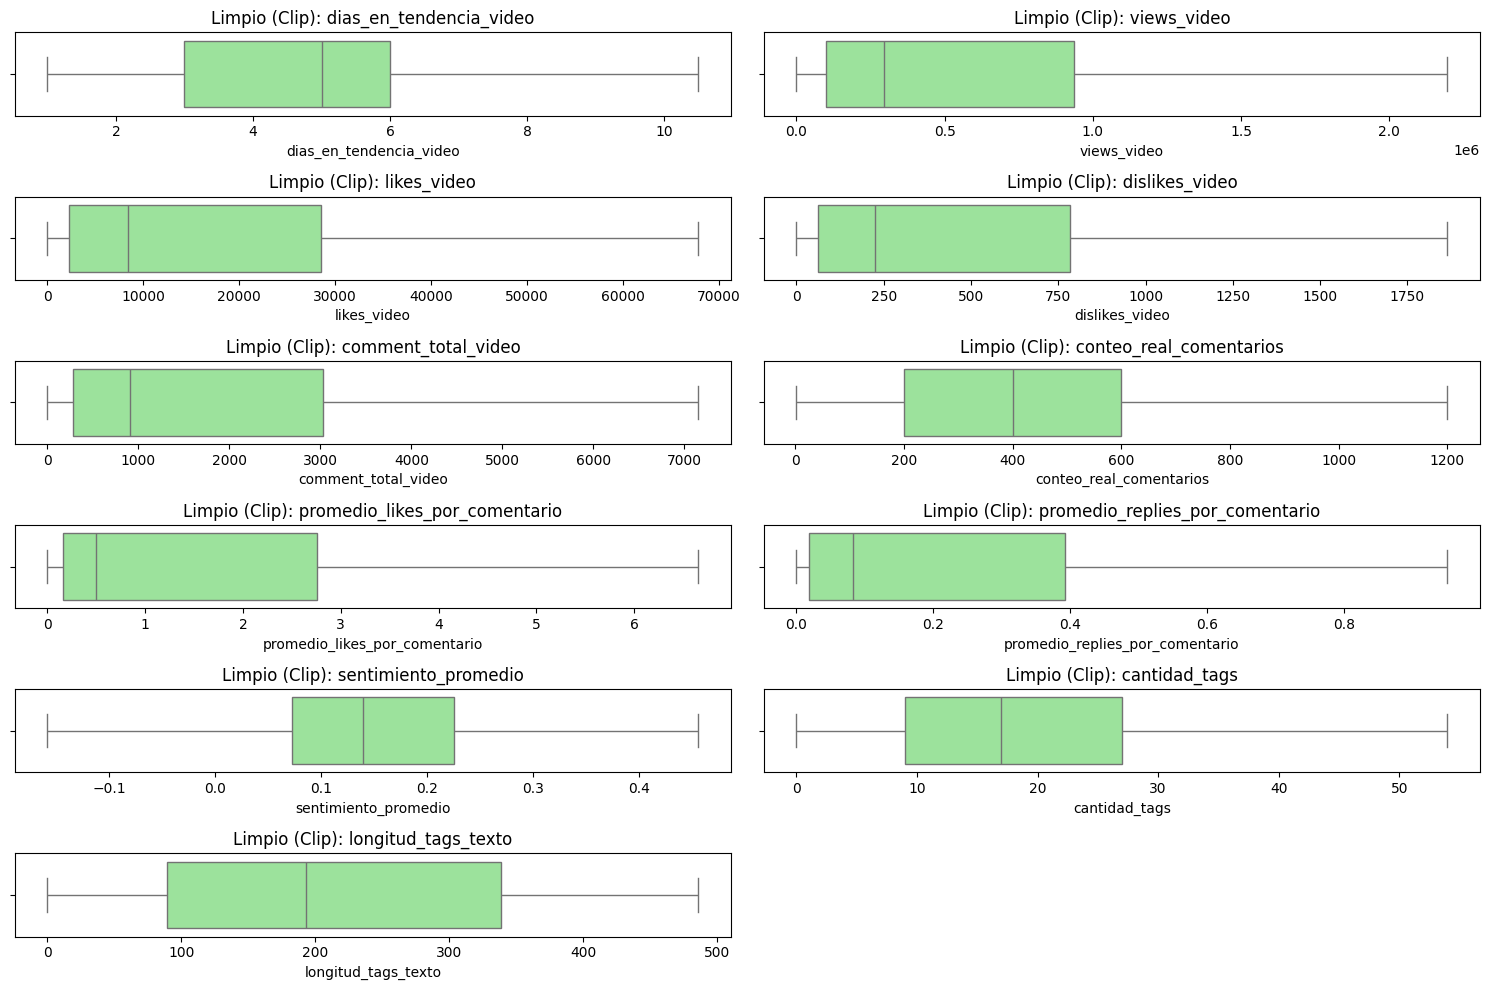

In [45]:
# Hacemos una copia para no alterar el original directamente
df_sin_outliers = df.copy()

#Aplicamos el tratamiento (Clip)
for col in numeric_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df_sin_outliers[col] = df_sin_outliers[col].clip(lower, upper)

#Visualización DESPUÉS de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df_sin_outliers[col], color='lightgreen')
    plt.title(f'Limpio (Clip): {col}')

plt.tight_layout()
plt.show()

### DETECCIÓN Y REMOCIÓN DE VARIABLE POCO POBLADAS

In [46]:
missing_ratio = df_sin_outliers.isnull().mean()
missing_ratio.sort_values(ascending=False)

sentimiento_promedio                  0.02534562
promedio_replies_por_comentario       0.02534562
promedio_likes_por_comentario         0.02534562
conteo_real_comentarios               0.02534562
dislikes_video                        0.00000000
likes_video                           0.00000000
views_video                           0.00000000
dias_en_tendencia_video               0.00000000
comment_total_video                   0.00000000
category_video_Comedy                 0.00000000
category_video_Education              0.00000000
category_video_Entertainment          0.00000000
category_video_Film & Animation       0.00000000
category_video_Gaming                 0.00000000
category_video_Howto & Style          0.00000000
category_video_Music                  0.00000000
category_video_News & Politics        0.00000000
category_video_People & Blogs         0.00000000
category_video_Pets & Animals         0.00000000
category_video_Science & Technology   0.00000000
category_video_Sport

In [47]:
low_populated_vars = missing_ratio[missing_ratio > 0.30].index.tolist()
low_populated_vars

[]

In [48]:
df.drop(columns=low_populated_vars, inplace=True)

#### DETECCIÓN Y REMOCIÓN DE VARIABLES UNITARIAS (UNARIAS)

In [49]:
list_columns = [
    col for col in df_sin_outliers.columns
    if df_sin_outliers[col].apply(lambda x: isinstance(x, list)).any()
]
unary_vars = [
    col for col in df_sin_outliers.columns
    if col not in list_columns and df_sin_outliers[col].nunique(dropna=True) == 1
]
unary_vars

[]

In [50]:
df_sin_outliers.drop(columns=unary_vars, inplace=True)
df_sin_outliers.head()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
0,3.00000000,1874297.00000000,46933.00000000,653.00000000,7154.75000000,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33.00000000,1,456.00000000
1,6.00000000,47188.00000000,410.00000000,19.00000000,109.00000000,291.00000000,3.87285223,0.95178277,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,23.00000000,1,381.00000000
2,2.00000000,197531.00000000,7176.00000000,117.00000000,291.00000000,200.00000000,6.65682408,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,44.00000000,1,445.00000000
3,7.00000000,159476.00000000,4995.00000000,31.00000000,368.00000000,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4.00000000,1,58.00000000
4,8.00000000,2146662.00000000,52598.00000000,1381.00000000,7154.75000000,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,15.00000000,1,239.00000000


### DETECCIÓN Y TRATAMIENTO DE VALORES AUSENTES

In [51]:
df_sin_outliers.isna().sum()

dias_en_tendencia_video                 0
views_video                             0
likes_video                             0
dislikes_video                          0
comment_total_video                     0
conteo_real_comentarios                44
promedio_likes_por_comentario          44
promedio_replies_por_comentario        44
sentimiento_promedio                   44
category_video_Comedy                   0
category_video_Education                0
category_video_Entertainment            0
category_video_Film & Animation         0
category_video_Gaming                   0
category_video_Howto & Style            0
category_video_Music                    0
category_video_News & Politics          0
category_video_People & Blogs           0
category_video_Pets & Animals           0
category_video_Science & Technology     0
category_video_Sports                   0
category_video_Travel & Events          0
category_video_None                     0
fuerza_canal_Small Tier           

In [52]:
# Columnas numéricas 
num_cols = ls_cont 

# Imputer para numéricas (mediana)
imputer_num = SimpleImputer(strategy='median')

# Aplicar imputación
df_sin_outliers[num_cols] = imputer_num.fit_transform(df_sin_outliers[num_cols])

In [53]:
df_sin_outliers.isna().sum()

dias_en_tendencia_video                0
views_video                            0
likes_video                            0
dislikes_video                         0
comment_total_video                    0
conteo_real_comentarios                0
promedio_likes_por_comentario          0
promedio_replies_por_comentario        0
sentimiento_promedio                   0
category_video_Comedy                  0
category_video_Education               0
category_video_Entertainment           0
category_video_Film & Animation        0
category_video_Gaming                  0
category_video_Howto & Style           0
category_video_Music                   0
category_video_News & Politics         0
category_video_People & Blogs          0
category_video_Pets & Animals          0
category_video_Science & Technology    0
category_video_Sports                  0
category_video_Travel & Events         0
category_video_None                    0
fuerza_canal_Small Tier                0
fuerza_canal_Top

In [54]:
df_final = df_sin_outliers.copy()
df_final.drop(columns=["conteo_real_comentarios"], inplace=True)
df_final.sample(10)

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
1163,9.00000000,850602.00000000,13735.00000000,1136.00000000,1263.00000000,0.22222222,0.02111111,0.03530003,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,23.00000000,1,445.00000000
1304,8.00000000,863700.00000000,17220.00000000,643.00000000,1156.00000000,0.26918239,0.01006289,0.07367169,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,15.00000000,1,128.00000000
914,6.00000000,47937.00000000,411.00000000,15.00000000,208.00000000,6.65682408,0.95178277,0.23738552,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,8.00000000,1,91.00000000
732,1.00000000,272376.00000000,4681.00000000,190.00000000,989.00000000,0.15000000,0.00000000,0.01650937,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,34.00000000,1,430.00000000
1658,1.00000000,166480.00000000,9985.00000000,82.00000000,578.00000000,0.13000000,0.00000000,0.18487636,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,18.00000000,1,231.00000000
418,7.00000000,516876.00000000,4351.00000000,182.00000000,139.00000000,2.62841530,0.45537341,0.21248489,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,12.00000000,1,89.00000000
1499,6.00000000,93745.00000000,180.00000000,121.00000000,188.00000000,6.65682408,0.68401487,0.01019425,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,5.00000000,1,77.00000000
436,6.00000000,262687.00000000,11805.00000000,586.00000000,2453.00000000,6.65682408,0.95178277,0.14193322,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,17.00000000,1,231.00000000
465,7.00000000,606989.00000000,26120.00000000,667.00000000,4471.00000000,0.05714286,0.03285714,0.26779237,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,24.00000000,1,241.00000000
960,4.00000000,91069.00000000,3801.00000000,79.00000000,328.00000000,1.09750000,0.23500000,0.28544438,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,19.00000000,1,290.00000000


In [67]:
df_sin_outliers.describe()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
count,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000
mean,4.60195853,636345.29025058,19307.53665035,534.69412442,2068.77577765,423.97695853,1.75695570,0.24945521,0.15182883,0.07142857,0.02649770,0.18375576,0.04377880,0.03744240,0.14516129,0.16129032,0.03917051,0.14112903,0.01094470,0.02937788,0.09447005,0.00576037,0.00230415,0.39919355,0.05645161,18.32488479,0.95046083,213.88594470
std,2.29909810,723015.48654140,23178.76649516,639.88222398,2418.60822934,246.39793156,2.29061628,0.32503457,0.10864197,0.25761358,0.16065627,0.38739648,0.20466154,0.18989796,0.35236488,0.36790450,0.19405636,0.34825492,0.10407283,0.16891198,0.29256583,0.07569999,0.04796002,0.48987375,0.23085824,12.04599172,0.21705340,142.21293329
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,2.00000000,0.00000000,0.00000000,-0.15799898,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
25%,3.00000000,99108.00000000,2239.00000000,62.00000000,276.00000000,200.00000000,0.16000000,0.02000000,0.07366202,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,9.00000000,1.00000000,89.00000000
50%,5.00000000,295596.50000000,8432.00000000,226.00000000,906.00000000,400.00000000,0.50000000,0.08333333,0.13984750,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,17.00000000,1.00000000,193.00000000
75%,6.00000000,937798.25000000,28482.75000000,783.00000000,3027.50000000,600.00000000,2.63533006,0.37500000,0.22285759,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,27.00000000,1.00000000,339.00000000
max,10.50000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,1200.00000000,6.65682408,0.95178277,0.45575190,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,54.00000000,1.00000000,486.00000000


## Targets

In [55]:
y_continuo= df_final.views_video
y_continuo.sample(10)

1394     69958.00000000
331    2162234.00000000
566     179860.00000000
342      89441.00000000
816     253051.00000000
36     1096509.00000000
320      37244.00000000
1429   1805704.00000000
1162    120109.00000000
571     411396.00000000
Name: views_video, dtype: float64

In [ ]:
y_discreto

## Modelado

### Segmentación de sets

In [56]:
X = df_final.drop(columns=['views_video'])
y = y_continuo

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
ls_cont.remove("conteo_real_comentarios")
ls_cont.remove("views_video")

In [64]:
ls_cont,ls_bin

(['dias_en_tendencia_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio',
  'cantidad_tags',
  'longitud_tags_texto'],
 ['category_video_Comedy',
  'category_video_Education',
  'category_video_Entertainment',
  'category_video_Film & Animation',
  'category_video_Gaming',
  'category_video_Howto & Style',
  'category_video_Music',
  'category_video_News & Politics',
  'category_video_People & Blogs',
  'category_video_Pets & Animals',
  'category_video_Science & Technology',
  'category_video_Sports',
  'category_video_Travel & Events',
  'category_video_None',
  'fuerza_canal_Small Tier',
  'fuerza_canal_Top Tier',
  'tiene_tags'])

In [70]:
#Definición de Escaladores y Modelos
escaladores = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust':RobustScaler()
}

modelos = {
    'Lineal': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Lars': Lars(),
    'Bayesiana': BayesianRidge(),
    'SGD': SGDRegressor(max_iter=1000, tol=1e-3) # El optimizador rápido 
}

resultados_cv = []
# Solo escalamos las continuas, las binarias (0/1) pasan directo
for esc_nombre, esc in escaladores.items():
    prepro = ColumnTransformer(transformers=[
        ('num', esc, ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])
    
    for mod_nombre, mod in modelos.items():
        pipeline = Pipeline([('prepro', prepro), ('regresor', mod)])
        
        # Cross-Validation
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=4, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std() # Qué tanto varían los resultados
        
        # Entrenamiento final para métricas de Test
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        r2_test = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        resultados_cv.append({
            'Configuración': f"{mod_nombre} ({esc_nombre})",
            'CV R2 Promedio': cv_mean,
            'CV R2 Desv. Est.': cv_std,
            'R2 Test': r2_test,
            'MAE Test': mae,
            'RMSE Test': rmse
        })

df_final = pd.DataFrame(resultados_cv).sort_values(by='CV R2 Promedio', ascending=False)
df_final

,Configuración,CV R2 Promedio,CV R2 Desv. Est.,R2 Test,MAE Test,RMSE Test
5,Bayesiana (Standard),0.81766937,0.02348146,0.81357902,201173.68398409,319519.38668561
19,Bayesiana (Robust),0.81759621,0.02343910,0.81357208,201247.67332361,319525.33416271
8,Ridge (MinMax),0.81711939,0.02348334,0.81342882,201863.59807365,319648.08375477
15,Ridge (Robust),0.81709892,0.02285274,0.81339990,201315.68022891,319672.85538638
1,Ridge (Standard),0.81706922,0.02280080,0.81339296,201302.87689336,319678.80397944
9,Lasso (MinMax),0.81671973,0.02264190,0.81344319,201419.41922242,319635.77547375
16,Lasso (Robust),0.81671919,0.02264092,0.81344403,201419.12062601,319635.05336543
2,Lasso (Standard),0.81671912,0.02264079,0.81344417,201419.12194899,319634.92963556
0,Lineal (Standard),0.81671527,0.02264036,0.81345013,201423.62755285,319629.82881528
14,Lineal (Robust),0.81671527,0.02264036,0.81345013,201423.62755285,319629.82881528


### GridSearch

En este caso ocupe Lasso con Min Max Scaler pero creo podemos elegir otro modelo aun mejor

In [ ]:
pipeline_final = Pipeline([
    ('prepro', ColumnTransformer(transformers=[
        ('num', MinMaxScaler(), ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])),
    ('regresor', Lasso(max_iter=10000))
])
# Rango exacto del for: de 0.1 a 10.0 (100 pasos)
# i/100 para i in range(10, 1010, 10) es equivalente a:
alphas_manuales = np.linspace(0.1, 10.0, 100)

#Ajustamos la malla de búsqueda (param_grid)
param_grid = {
    'regresor__alpha': alphas_manuales
}

# Configuramos el GridSearchCV
# cv=4 y n_jobs=-1 para velocidad
grid_lasso = GridSearchCV(
    pipeline_final, 
    param_grid, 
    cv=4, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

# Entrenamos
grid_lasso.fit(X_train, y_train)

df_res_automatico = pd.DataFrame(grid_lasso.cv_results_)
df_res_final = df_res_automatico[['param_regresor__alpha', 'mean_test_score', 'std_test_score']]
df_res_final.columns = ['alpha', 'r2_mean', 'r2_std']

df_res_final


Fitting 4 folds for each of 100 candidates, totalling 400 fits


,alpha,r2_mean,r2_std
0,0.10000000,0.81671572,0.02264052
1,0.20000000,0.81671617,0.02264067
2,0.30000000,0.81671661,0.02264082
3,0.40000000,0.81671706,0.02264098
4,0.50000000,0.81671751,0.02264113
...,...,...,...
95,9.60000000,0.81675602,0.02265543
96,9.70000000,0.81675642,0.02265558
97,9.80000000,0.81675682,0.02265574
98,9.90000000,0.81675722,0.02265590


In [74]:
print(f"\nMejor Alpha: {grid_lasso.best_params_}")


Mejor Alpha: {'regresor__alpha': np.float64(10.0)}


In [ ]:
# Definimos el Pipeline con el ganador absoluto
mejor_pipe = Pipeline([
    ('prepro', ColumnTransformer(transformers=[
        ('num', StandardScaler(), ls_cont),
        ('bin', 'passthrough', ls_bin)
    ])),
    ('regresor', BayesianRidge())
])

# Entrenamos con el set de entrenamiento completo
mejor_pipe.fit(X_train, y_train)

# Extraemos la importancia de las variables (Coeficientes)
nombres_variables = ls_cont + ls_bin
pesos = mejor_pipe.named_steps['regresor'].coef_

df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Impacto': pesos
}).sort_values(by='Impacto', ascending=False)

# Mostramos las 10 que más suben las vistas
print("Top Variables que aumentan las vistas:")
print(df_importancia.head(10))

Top Variables que aumentan las vistas:
                           Variable         Impacto
1                       likes_video 394360.09573763
2                    dislikes_video 258697.53024943
18    category_video_Pets & Animals 153350.63576917
12  category_video_Film & Animation  90080.05625821
24            fuerza_canal_Top Tier  50205.38395011
8               longitud_tags_texto  43822.91506912
20            category_video_Sports  42068.51036086
23          fuerza_canal_Small Tier  30191.30198384
0           dias_en_tendencia_video  27601.54994760
3               comment_total_video  19747.62683754
